In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

website used: Ambitionbox

### Many sites dont allow bots to perform actions on them thus ERROR 403

In [2]:
requests.get('https://www.ambitionbox.com/list-of-companies?designation=machine-learning-engineer&sortBy=topPaying')

<Response [403]>

### adding a header replicates normal use

In [3]:
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36'}
webpage=requests.get('https://www.ambitionbox.com/list-of-companies?designation=machine-learning-engineer&sortBy=topPaying',headers=headers).text

'<!doctype html>\n<html data-n-head-ssr lang="en" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D">\n  <head >\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width,initial-scale=1,minimum-scale=1">\n    <meta http-equiv="X-UA-Compatible" content="IE=edge"> \n    <link rel="manifest" href="/assets/next/manifest.json">\n    <style>@media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}</style>\n    <script src="/static/js/env-runtime.js" defer></script>\n    <script>window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()</script>\n    <script>window.Prism=window.Prism||{},window.Prism.manual=!0</script>\n    <title>Highest Paying Companies for Machine Learning Engineer in India | AmbitionBox</title><meta data-n-head="ssr" name="copyright" content="2026 AmbitionBox"><meta data-n-head="ssr" name=
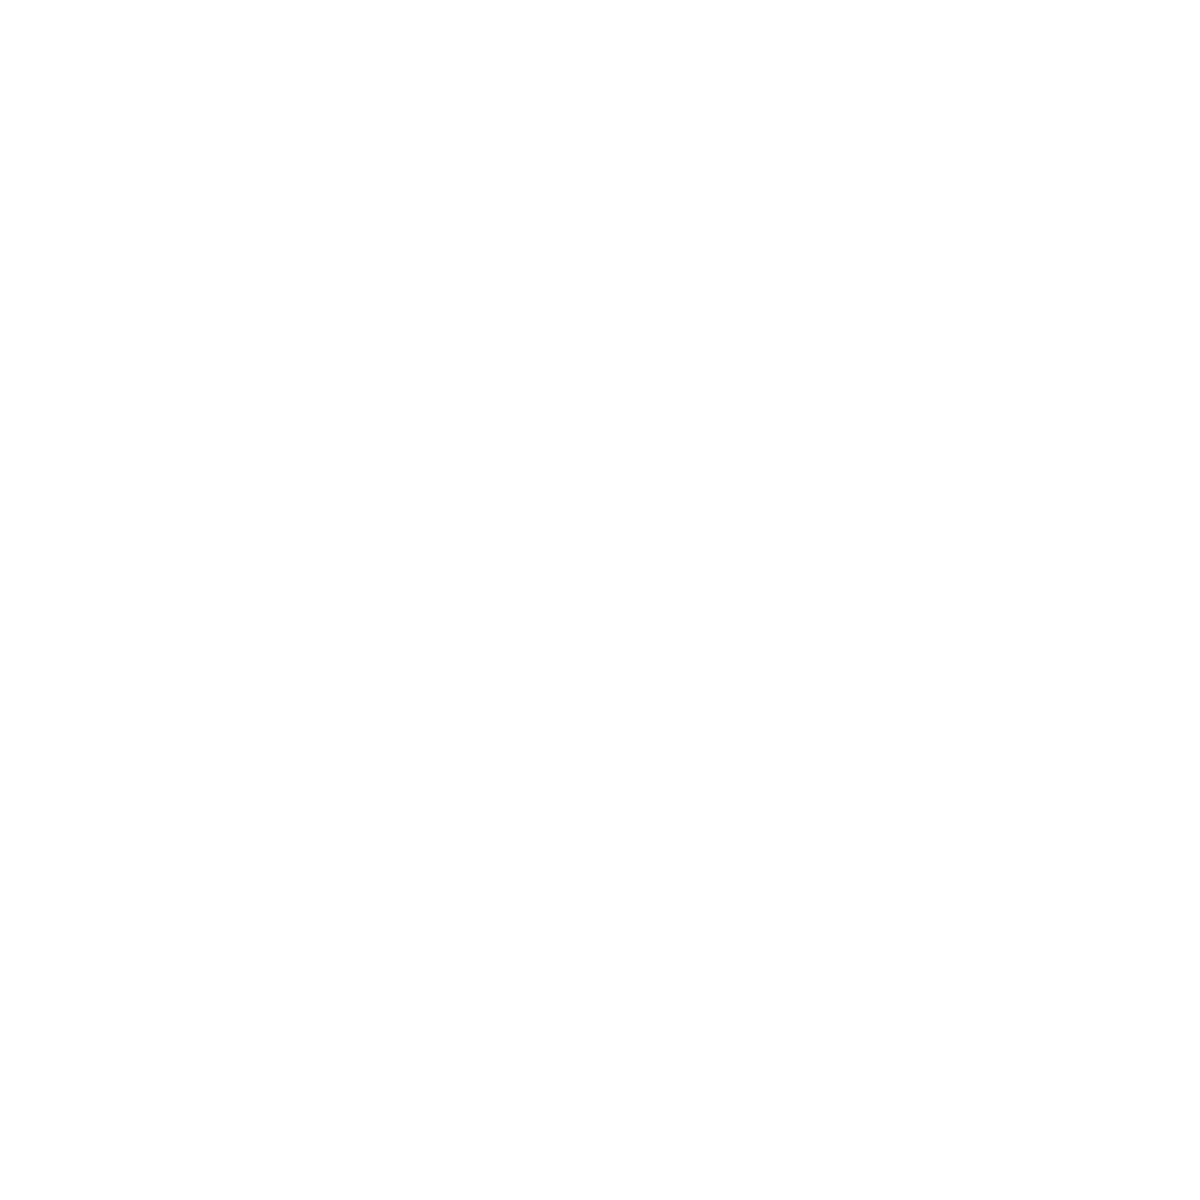

In [4]:
webpage

## Using beautifulsoup to traverse this webpage's script

In [5]:
soup = BeautifulSoup(webpage, 'lxml')

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Highest Paying Companies for Machine Learning Engineer in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content=
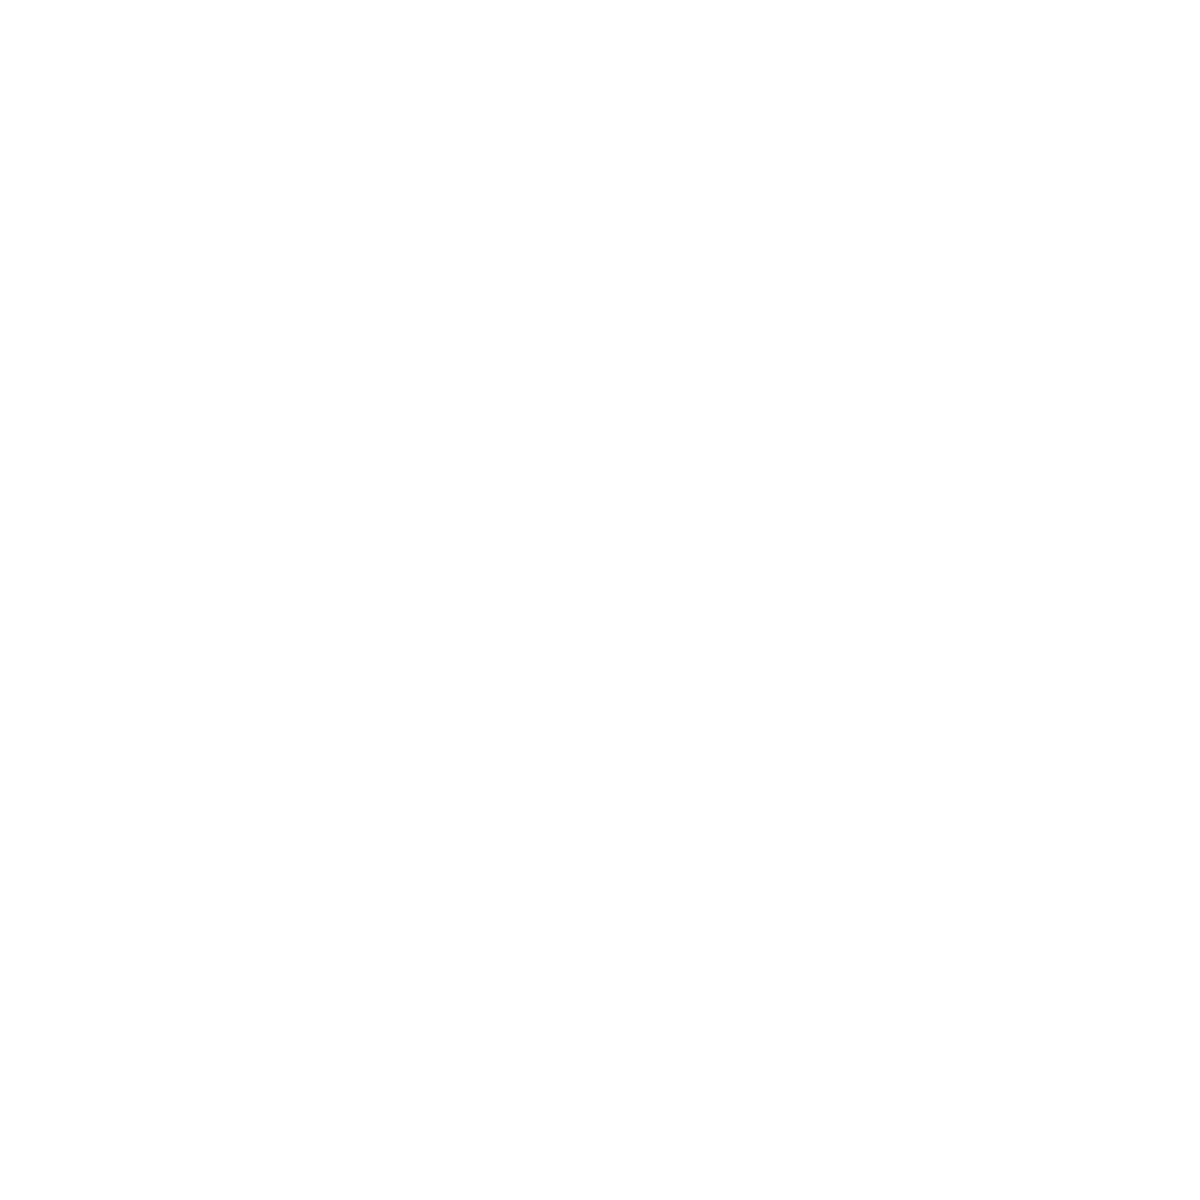

In [6]:
print(soup.prettify())

Finding all h1 tags

In [7]:
soup.find_all('h1')[0].text #here .text gives no code only text

'\n\t\t\t\t\t\t\t\tTop Paying Companies for Machine Learning Engineer in India\n\t\t\t\t\t\t\t\t'

### u can use multiple factors/attributes to locate 

In [8]:
soup.find_all('h2', class_='companyCardWrapper__companyName')

[<h2 class="companyCardWrapper__companyName" title="Google">
 									Google
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Escalent">
 									Escalent
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="PayPal">
 									PayPal
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="SAP">
 									SAP
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Qualcomm">
 									Qualcomm
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Fractal Analytics">
 									Fractal Analytics
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Tiger Analytics">
 									Tiger Analytics
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Samsung Research">
 									Samsung Research
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Anko">
 									Anko
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="IBM">
 									IBM
 								</h2>,
 <h2 cla

printing all the names of the company

In [9]:
for i in soup.find_all('h2', class_='companyCardWrapper__companyName'):

    print(i.text.strip())

Google
Escalent
PayPal
SAP
Qualcomm
Fractal Analytics
Tiger Analytics
Samsung Research
Anko
IBM
Deloitte
Jio Platforms
Quantiphi Analytics Solutions Private Limited
Accenture
DeepEdge
Oneture Technologies
Ankercloud
HCLTech
Capgemini
Amazon


*make a list named Cname for company name*

In [10]:
Cname = []
for i in soup.find_all('h2', class_='companyCardWrapper__companyName'):
    Cname.append(i.text.strip())

### for number of reviews

In [11]:
for i in soup.find_all('span', class_='companyCardWrapper__companyRatingCount'):
    print(i.text.strip())

(1.9k)
(105)
(1.2k)
(2k)
(1.2k)
(1.1k)
(999)
(1.3k)
(119)
(25.9k)
(23.5k)
(2.1k)
(989)
(74.1k)
(9)
(35)
(37)
(46.4k)
(53.9k)
(31.7k)


*made a list for total reviews*

In [12]:
totalReviews = []
for i in soup.find_all('span', class_='companyCardWrapper__companyRatingCount'):
    totalReviews.append(i.text.strip())

In [13]:
len(soup.find_all('span'))

469

In [14]:
soup.find_all('span') #for number fo salaries posted length shld be 20 but 469

[<span class="plus">+</span>,
 <span class="badge" id="badge-count" style="padding:;display:none;"></span>,
 <span class="nav-group-link__label" data-v-7add770d="">Home</span>,
 <span class="nav-group-link__label" data-v-7add770d="">Companies</span>,
 <span class="nav-group-link__label" data-v-7add770d="">Reviews</span>,
 <span class="nav-group-link__label" data-v-7add770d="">Salaries</span>,
 <span class="nav-group-link__label" data-v-7add770d="">Interview Questions</span>,
 <span class="nav-group-link__label" data-v-7add770d="">Jobs</span>,
 <span class="nav-communities__header-label" data-v-6c7fc088="">Communities</span>,
 <span class="nav-communities-item__label" data-v-5de23844="">My Company</span>,
 <span class="nav-communities-item__label" data-v-5de23844="">My Role</span>,
 <span class="nav-group-header__label" data-v-7add770d="">Tools</span>,
 <span class="nav-menu-item__label" data-v-2555b3ac="">Compare Companies</span>,
 <span class="nav-menu-item__label" data-v-2555b3ac="">

In [15]:
### Solution: build a container within which u can apply operation

In [16]:
container = soup.find_all('div', class_='detailedRange nologin')

In [17]:
len(container)

20

In [18]:
for i in container:
    print(i.find_all('span')[0].text.strip().replace(" ",""))

₹
										38.1
										L/yr
										-₹
										49.2
										L/yr
₹
										28.5
										L/yr
										-₹
										33.5
										L/yr
₹
										25.3
										L/yr
										-₹
										30.7
										L/yr
₹
										23
										L/yr
										-₹
										32.8
										L/yr
₹
										22.8
										L/yr
										-₹
										29
										L/yr
₹
										20.3
										L/yr
										-₹
										26.4
										L/yr
₹
										20.4
										L/yr
										-₹
										22.6
										L/yr
₹
										17.1
										L/yr
										-₹
										19.3
										L/yr
₹
										14.4
										L/yr
										-₹
										19.3
										L/yr
₹
										13.3
										L/yr
										-₹
										18.2
										L/yr
₹
										13.4
										L/yr
										-₹
										17.6
										L/yr
₹
										12.2
										L/yr
										-₹
										17.4
										L/yr
₹
										11.9
										L/yr
										-₹
										14.1
										L/yr
₹
										11.5
										L/

**thought**: it happened coz there wasnt a clear differentiator class like 'detailedRange nologin' for that perticular value(salary range) so we made a container which has differentiable class and searched within that

In [19]:
salaryRange=[]
for i in container:
    salaryRange.append(i.find_all('span')[0].text.strip())

In [20]:
salaryRange

['₹\n\t\t\t\t\t\t\t\t\t\t38.1\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t\t\t\t\t\t\t\t\t\t- ₹\n\t\t\t\t\t\t\t\t\t\t49.2\n\t\t\t\t\t\t\t\t\t\tL/yr',
 '₹\n\t\t\t\t\t\t\t\t\t\t28.5\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t\t\t\t\t\t\t\t\t\t- ₹\n\t\t\t\t\t\t\t\t\t\t33.5\n\t\t\t\t\t\t\t\t\t\tL/yr',
 '₹\n\t\t\t\t\t\t\t\t\t\t25.3\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t\t\t\t\t\t\t\t\t\t- ₹\n\t\t\t\t\t\t\t\t\t\t30.7\n\t\t\t\t\t\t\t\t\t\tL/yr',
 '₹\n\t\t\t\t\t\t\t\t\t\t23\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t\t\t\t\t\t\t\t\t\t- ₹\n\t\t\t\t\t\t\t\t\t\t32.8\n\t\t\t\t\t\t\t\t\t\tL/yr',
 '₹\n\t\t\t\t\t\t\t\t\t\t22.8\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t\t\t\t\t\t\t\t\t\t- ₹\n\t\t\t\t\t\t\t\t\t\t29\n\t\t\t\t\t\t\t\t\t\tL/yr',
 '₹\n\t\t\t\t\t\t\t\t\t\t20.3\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t\t\t\t\t\t\t\t\t\t- ₹\n\t\t\t\t\t\t\t\t\t\t26.4\n\t\t\t\t\t\t\t\t\t\tL/yr',
 '₹\n\t\t\t\t\t\t\t\t\t\t20.4\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t\t\t\t\t\t\t\t\t\t- ₹\n\t\t\t\t\t\t\t\t\t\t22.6\n\t\t\t\t\t\t\t\t\t\tL/yr',
 '₹\n\t\t\t\t\t\t\t\t\t\t17.1\n\t\t\t\t\t\t\t\t\t\tL/yr\n\t

### salaryRange1 is the cleaned version of salaryRange: 1st split() everythign then join with a single space using join()

list created

In [21]:
salaryRange1=[]
for i in salaryRange:
    salaryRange1.append(" ".join(i.split()))

In [22]:
salaryRange1

['₹ 38.1 L/yr - ₹ 49.2 L/yr',
 '₹ 28.5 L/yr - ₹ 33.5 L/yr',
 '₹ 25.3 L/yr - ₹ 30.7 L/yr',
 '₹ 23 L/yr - ₹ 32.8 L/yr',
 '₹ 22.8 L/yr - ₹ 29 L/yr',
 '₹ 20.3 L/yr - ₹ 26.4 L/yr',
 '₹ 20.4 L/yr - ₹ 22.6 L/yr',
 '₹ 17.1 L/yr - ₹ 19.3 L/yr',
 '₹ 14.4 L/yr - ₹ 19.3 L/yr',
 '₹ 13.3 L/yr - ₹ 18.2 L/yr',
 '₹ 13.4 L/yr - ₹ 17.6 L/yr',
 '₹ 12.2 L/yr - ₹ 17.4 L/yr',
 '₹ 11.9 L/yr - ₹ 14.1 L/yr',
 '₹ 11.5 L/yr - ₹ 13.6 L/yr',
 '₹ 10 L/yr - ₹ 14.1 L/yr',
 '₹ 10.6 L/yr - ₹ 12.3 L/yr',
 '₹ 9.1 L/yr - ₹ 13 L/yr',
 '₹ 9.6 L/yr - ₹ 12.5 L/yr',
 '₹ 9.7 L/yr - ₹ 11.8 L/yr',
 '₹ 7.2 L/yr - ₹ 10.7 L/yr']

In [23]:
df = {'Company_Name': Cname, 'Total_reviews': totalReviews, 'Salary Range': salaryRange1}
df = pd.DataFrame(df)
df

,Company_Name,Total_reviews,Salary Range
0,Google,(1.9k),₹ 38.1 L/yr - ₹ 49.2 L/yr
1,Escalent,(105),₹ 28.5 L/yr - ₹ 33.5 L/yr
2,PayPal,(1.2k),₹ 25.3 L/yr - ₹ 30.7 L/yr
3,SAP,(2k),₹ 23 L/yr - ₹ 32.8 L/yr
4,Qualcomm,(1.2k),₹ 22.8 L/yr - ₹ 29 L/yr
5,Fractal Analytics,(1.1k),₹ 20.3 L/yr - ₹ 26.4 L/yr
6,Tiger Analytics,(999),₹ 20.4 L/yr - ₹ 22.6 L/yr
7,Samsung Research,(1.3k),₹ 17.1 L/yr - ₹ 19.3 L/yr
8,Anko,(119),₹ 14.4 L/yr - ₹ 19.3 L/yr
9,IBM,(25.9k),₹ 13.3 L/yr - ₹ 18.2 L/yr


In [36]:
final=pd.DataFrame()
for j in range(1,3):
    url = f'https://www.ambitionbox.com/list-of-companies?designation=machine-learning-engineer&sortBy=topPaying&page={j}'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/135.0.0.0 Safari/537.36'}
    webpage=requests.get(url,headers=headers).text
    soup=BeautifulSoup(webpage, 'lxml')
    
    Cname = []
    for i in soup.find_all('h2', class_='companyCardWrapper__companyName'):
        Cname.append(i.text.strip())

    totalReviews = []
    for i in soup.find_all('span', class_='companyCardWrapper__companyRatingCount'):
        totalReviews.append(i.text.strip())

    container = soup.find_all('div', class_='detailedRange nologin')
        
    salaryRange=[]
    for i in container:
        salaryRange.append(i.find_all('span')[0].text.strip())

    salaryRange1=[]
    for i in salaryRange:
        salaryRange1.append(" ".join(i.split()))

    df = {'Company Name': Cname, 'Total reviews': totalReviews, 'Salary Range': salaryRange1}
    df = pd.DataFrame(df)
    final=pd.concat([final,df], ignore_index=True)


In [37]:
final

,Company Name,Total reviews,Salary Range
0,Google,(1.9k),₹ 38.1 L/yr - ₹ 49.2 L/yr
1,Escalent,(105),₹ 28.5 L/yr - ₹ 33.5 L/yr
2,PayPal,(1.2k),₹ 25.3 L/yr - ₹ 30.7 L/yr
3,SAP,(2k),₹ 23 L/yr - ₹ 32.8 L/yr
4,Qualcomm,(1.2k),₹ 22.8 L/yr - ₹ 29 L/yr
5,Fractal Analytics,(1.1k),₹ 20.3 L/yr - ₹ 26.4 L/yr
6,Tiger Analytics,(999),₹ 20.4 L/yr - ₹ 22.6 L/yr
7,Samsung Research,(1.3k),₹ 17.1 L/yr - ₹ 19.3 L/yr
8,Anko,(119),₹ 14.4 L/yr - ₹ 19.3 L/yr
9,IBM,(25.9k),₹ 13.3 L/yr - ₹ 18.2 L/yr
